In [ ]:
num_epochs = 10
neurons_per_layer = [64, 128, 256]
model_name = "scaled_data_model_"

In [2]:
import numpy as np
import nn_fncs
mat_data = nn_fncs.read_mat_workspace('Thrust_data.mat')
nn_in = mat_data.get('nn_in')
nn_out = mat_data.get('nn_out')
# Get every 5th data sample
nn_in = nn_in[:, ::5, :]
nn_out = nn_out[:, ::5, :]
# remove zero columns in nn_out
nn_out1 = nn_out[:, :, ~np.all(nn_out == 0, axis=(0, 1))]
nn_out2 = nn_out[:, :, [0, 1, 2, 3, 7, 10, 11]] 
# Verify that all elements of nn_out1 and nn_out2 are the same
assert np.array_equal(nn_out1, nn_out2), "The arrays are not equal"
nn_out = nn_out2
print(f'nn_in shape: {nn_in.shape}')  # (num_trajectories, num_time_steps, num_inputs)
print(f'nn_out shape: {nn_out.shape}')      # (num_trajectories, num_time_steps, num_outputs)
# Reshape to 2D arrays for training
num_trajectories, num_time_steps, num_inputs = nn_in.shape
num_outputs = nn_out.shape[2]
nn_in = nn_in.reshape(-1, num_inputs)
nn_out = nn_out.reshape(-1, num_outputs)
print(f'Reshaped nn_in shape: {nn_in.shape}')  # (num_trajectories * num_time_steps, num_inputs)
print(f'Reshaped nn_out shape: {nn_out.shape}')  # (num_

nn_in shape: (329, 2000, 16)
nn_out shape: (329, 2000, 7)
Reshaped nn_in shape: (658000, 16)
Reshaped nn_out shape: (658000, 7)


In [3]:
from sklearn import preprocessing
in_scaled = preprocessing.StandardScaler().fit_transform(nn_in)
print(f'u_scaled shape: {in_scaled.shape}')

u_scaled shape: (658000, 16)


In [4]:
# Check min and max values of nn_in and nn_out per column in the last axis
for i in range(in_scaled.shape[1]):
    print(f'nn_in column {i}: min={np.min(in_scaled[:, i])}, max={np.max(in_scaled[:, i])}')

for i in range(nn_out.shape[1]):
    print(f'nn_out column {i}: min={np.min(nn_out[:, i])}, max={np.max(nn_out[:, i])}')


nn_in column 0: min=-3.200675457136383, max=7.357081106728632
nn_in column 1: min=-9.492274487455283, max=8.83143743179315
nn_in column 2: min=-3.0202468870259325, max=1.3495316862207007
nn_in column 3: min=-1.6664234776669802, max=1.8085564592733345
nn_in column 4: min=-2.3033254613174705, max=4.1657916133142106
nn_in column 5: min=-14.901688819608076, max=13.129948353686611
nn_in column 6: min=-1.8172850986697748, max=1.8983269593717815
nn_in column 7: min=-2.2212561508777267, max=2.255017406281213
nn_in column 8: min=0.0, max=0.0
nn_in column 9: min=-2.1548740422387436, max=2.1380890634047875
nn_in column 10: min=-4.05689018920978, max=2.7774110562908687
nn_in column 11: min=-1.999394944746261, max=2.0371429974001978
nn_in column 12: min=-1.8010354593715507, max=1.8035176660829464
nn_in column 13: min=-6.320453378162323, max=6.307724790561712
nn_in column 14: min=-1.8010354593715507, max=1.8035176660829464
nn_in column 15: min=-1.7272260525867276, max=1.7272260525867276
nn_out colum

In [5]:
# Create data loaders
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split

# Split into training and validation sets (80% train, 20% val)
# separate into training and validation sets
split_ratio = 0.75
split_index = int(in_scaled.shape[0] * split_ratio)
# Shuffle data before splitting
indices = np.arange(in_scaled.shape[0])
np.random.shuffle(indices)
in_scaled = in_scaled[indices]
nn_out = nn_out[indices]

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# Split data into training and validation sets
train_dataset = torch.utils.data.TensorDataset(torch.tensor(in_scaled[:split_index], dtype=torch.float32).to(device), 
                                               torch.tensor(nn_out[:split_index], dtype=torch.float32).to(device))
valid_dataset = torch.utils.data.TensorDataset(torch.tensor(in_scaled[split_index:], dtype=torch.float32).to(device), 
                                               torch.tensor(nn_out[split_index:], dtype=torch.float32).to(device))

train_loader = DataLoader(train_dataset, batch_size=1000, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1000, shuffle=False)

In [6]:
# MODEL STRUCTURE

import torch
import torch.nn as nn
import torch.nn.functional as F

n_neurons = 512
class ThrustModel(nn.Module):
    def __init__(self, in_size=1, out_size=3):  
        super(ThrustModel, self).__init__()
        # Fully connected layers
        self.fc1 = nn.Linear(in_size, n_neurons) 
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.fc3 = nn.Linear(n_neurons, n_neurons)
        self.fc4 = nn.Linear(n_neurons, n_neurons)
        self.fc5 = nn.Linear(n_neurons, n_neurons)
        self.fc6 = nn.Linear(n_neurons, n_neurons)
        self.fc7 = nn.Linear(n_neurons, n_neurons)
        self.fc8 = nn.Linear(n_neurons, n_neurons)
        self.fc9 = nn.Linear(n_neurons, n_neurons)
        self.output = nn.Linear(n_neurons, out_size)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, x):
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        x = F.relu(self.fc4(x))
        x = self.dropout(x)
        x = F.relu(self.fc5(x))
        x = self.dropout(x)
        x = F.relu(self.fc6(x))
        x = self.dropout(x)
        x = F.relu(self.fc7(x))
        x = self.dropout(x)
        x = F.relu(self.fc8(x))
        x = self.dropout(x)
        x = F.relu(self.fc9(x))
        x = self.dropout(x)
        x = self.output(x)
        return x

model = ThrustModel(nn_in.shape[1], nn_out.shape[1])

# Print model summary
print(model)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params}')

ThrustModel(
  (fc1): Linear(in_features=16, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=512, bias=True)
  (fc4): Linear(in_features=512, out_features=512, bias=True)
  (fc5): Linear(in_features=512, out_features=512, bias=True)
  (fc6): Linear(in_features=512, out_features=512, bias=True)
  (fc7): Linear(in_features=512, out_features=512, bias=True)
  (fc8): Linear(in_features=512, out_features=512, bias=True)
  (fc9): Linear(in_features=512, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=7, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
Total trainable parameters: 2113543


In [7]:
# One step training
import torch.optim as optim
from torcheval.metrics.functional import mean_squared_error, r2_score
from scipy.integrate import odeint

def one_step_training(model, criterion, optimizer, input_data, target, r2_scalar = True):
    t = 0
    loss = 0.0
    xk = target[0]
    predictions = torch.zeros_like(target)
    for i in range(target.shape[0]-1):

        with torch.set_grad_enabled(True):
            # Forward pass
            pred = model(input_data)  # Integrate over a small time step
            loss = criterion(pred, target)
            # Backward and optimize
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
    if r2_scalar:
        r2 = r2_score(pred, target, multioutput='uniform_average')
    else:
        r2 = r2_score(pred, target, multioutput='raw_values')
    return pred, loss, r2

In [84]:
# Example training step
from random import randint
model.load_state_dict(torch.load('thrust_model_v2_0.1306980233.pt'))
# Select a random trajectory id
id = randint(0, nn_in.shape[0]-1)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f'Training on trajectory id: {id}')
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
in_data, out_data = next(iter(train_loader))
pred, loss, r2 = one_step_training(model, 
                                   criterion, 
                                   optimizer, 
                                   in_data.to(device), 
                                   out_data.to(device), r2_scalar=False)

print(f'Loss: {loss.item()}, R2: {r2}')

Training on trajectory id: 585656
Loss: 0.13139796257019043, R2: tensor([0.2916, 0.6066, 0.1396, 0.9509, 0.7960, 0.1702, 0.1365],
       device='cuda:0')


In [9]:
# Complete training loop
num_epochs = 1
best_r2 = -float('inf')
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
model.train()
history_loss = []
for epoch in range(num_epochs):
    epoch_loss = 0.0
    epoch_r2 = 0.0
    for in_tensor, out_tensor in train_loader:
        pred, loss, r2 = one_step_training(model, 
                                            criterion, 
                                            optimizer,
                                            in_tensor,
                                            out_tensor)
        epoch_loss += loss.item()*in_tensor.size(0)
        epoch_r2 += r2.item()*in_tensor.size(0)
    epoch_loss /= (train_loader.dataset.tensors[0].shape[0])
    epoch_r2 /= (train_loader.dataset.tensors[1].shape[0])
    #if (epoch+1) % 100 == 0:
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6e}, R2: {epoch_r2:.6e}')
    if epoch_r2 > best_r2:
        best_r2 = epoch_r2
        nn_fncs.save_best_model(model, epoch_r2, 0, model_name='thrust_model_norm')
    history_loss.append(epoch_loss)


Epoch [1/1], Loss: 4.296488e-02, R2: 7.831559e-01
New best model saved: thrust_model_norm_0.7831559277.pt (Accuracy: 0.7831559277)


In [21]:
# One step eval
import torch.optim as optim
from torcheval.metrics.functional import mean_squared_error, r2_score
from scipy.integrate import odeint

def one_eval_step(model, input_data, target, r2_multiout=False):
    loss = 0.0
    model.eval()

    for i in range(target.shape[0]-1):

        with torch.no_grad():
            # Forward pass
            pred = model(input_data)  # Integrate over a small time step
    mse = mean_squared_error(pred, target)
            # Backward and optimize
    if r2_multiout:
        r2 = r2_score(pred, target, multioutput='raw_values')
    else:    
        r2 = r2_score(pred, target)
    return pred, mse, r2

In [95]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
in_data, out_data = next(iter(valid_loader))
pred, mse, r2 = one_eval_step(model, in_data.to(device), out_data.to(device), r2_multiout=True)
_, _, r2_total = one_eval_step(model, in_data.to(device), out_data.to(device), r2_multiout=False)
print(f'MSE: {mse}', f'R2: {r2}', f'R2 Total: {r2_total}')
# Print real vs predicted for first 10 samples
print("Real vs Predicted (first 10 samples):")
for i in range(10):
    print(f"Real: \n{out_data[i]}, \nPredicted: \n{pred[i].cpu().numpy()}")

MSE: 0.0991310328245163 R2: tensor([ 0.4265,  0.3436,  0.1991,  0.6283,  0.6265,  0.1714, -0.0072],
       device='cuda:0') R2 Total: 0.3411903977394104
Real vs Predicted (first 10 samples):
Real: 
tensor([ 0.2039, -0.1002, -0.2960,  0.2647,  0.1672, -0.1657,  0.0163],
       device='cuda:0'), 
Predicted: 
[ 0.4292016  -0.20911309 -0.3064609   0.26357776  0.10965178 -0.18844575
  0.11390799]
Real: 
tensor([ 0.0018, -0.1912,  0.0010,  0.1719,  0.1235,  0.0006, -0.0421],
       device='cuda:0'), 
Predicted: 
[ 0.0031814  -0.16831425 -0.02083236  0.18908551  0.09933345 -0.01303571
 -0.01984626]
Real: 
tensor([ 0.1434, -0.1975, -0.0359, -0.3478, -0.0490, -0.0201,  0.0184],
       device='cuda:0'), 
Predicted: 
[ 0.12506035 -0.22764447 -0.03742352 -0.35241538 -0.11977047 -0.0351319
  0.02020463]
Real: 
tensor([ 0.1999, -0.0717,  0.3194, -0.2136, -0.1611,  0.1789, -0.0170],
       device='cuda:0'), 
Predicted: 
[-0.00979739 -0.1326968  -0.03968829  0.03438611  0.03901753 -0.03273931
  0.0184

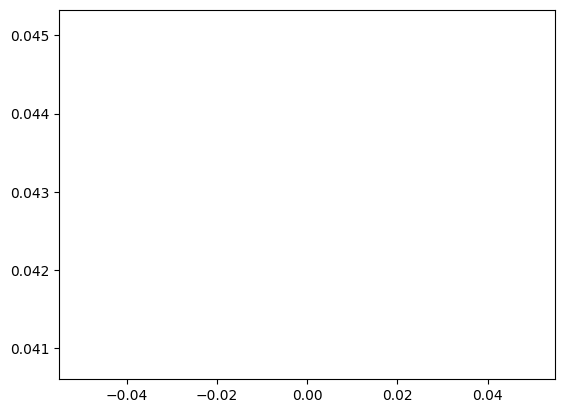

In [10]:

# plot training loss
import matplotlib.pyplot as plt
plt.plot(history_loss)